# Which CAM designs could be built — the phase 1 screen

`PROPOSAL.md` risk 1 says the decisive question is one the repository never
measured: **what fraction of a row's width does the Hamming tolerance have to
be?** A CAM fires when a query lands within that many bits of a stored row. The
JSSC 2025 macro demonstrates 8 bits in a 64-bit word — 12.5 % — and a coin flip
puts the ceiling near 50 %. If a design needs more than silicon offers, nothing
else about it matters.

This notebook answers that for five CAM acquisition families, from distance
tables alone. No threshold is chosen and no decision is made, which is what makes
it cheap and family-agnostic. Section 4.6 of `docs/CAM_FAMILY_STUDY.md` defines
the two distributions:

* **D_true** — the distance from a query at a satellite's own code phase to the
  row that stands for it, kept per look. The tolerance has to be at least this.
* **D_wrong** — the distance to every row of a PRN the record does not contain.
  The tolerance has to be below this. Its mean and spread are the chance floor
  measured *with satellites present*, which is the floor that matters: a strong
  satellite cross-correlates with the other PRNs' codes by a fixed amount that a
  pure-noise measurement never sees.

The numbers below come from 20 calibration skies (set A) at three record
scalings, 60 simulated records and 642 satellites. Regenerate them with
`uv run python scripts/run_family_screen.py`, which takes about three quarters of
an hour; they are checked in so this notebook opens instantly.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RESULTS = Path("../docs/screen_results.json")
assert RESULTS.is_file(), "Run scripts/run_family_screen.py first."
results = json.loads(RESULTS.read_text())
families = {entry["family"]: entry for entry in results["families"]}

# The two lines every family is judged against, from PROPOSAL.md.
SILICON = 8 / 64        # JSSC 60(8):3009 - 8 bits of a 64 bit word
CEILING = 0.5           # Where an unrelated row already sits

# Categorical slots 1-6, assigned in fixed order and never cycled. Markers carry
# the same identity, so the chart survives print and colour vision deficiency.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
MARKERS = ["o", "s", "^", "D", "v", "P"]
SURFACE, INK, MUTED = "#fcfcfb", "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.figsize": (9, 4.6), "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE, "axes.edgecolor": MUTED, "axes.labelcolor": INK,
    "axes.grid": True, "grid.alpha": 0.25, "grid.color": MUTED,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
})

print(f"{results['config']['n_calibration_skies']} skies, "
      f"scalings {results['config']['scalings_dbhz']} dB-Hz")
for name, entry in families.items():
    print(f"  {name:22s} {entry['n_rows']:6d} x {entry['n_columns']:5d} bits, "
          f"{entry['n_looks']:5d} looks, {entry['seconds']:5.0f} s")

20 skies, scalings [54.0, 45.0, 36.0] dB-Hz
  baseline                 1344 x  2046 bits,  5781 looks,    97 s
  code-only (quadrant)       64 x  2046 bits,  5781 looks,  1499 s
  code-only (exact)          64 x  2046 bits,  1108 looks,   347 s
  thermometer              1344 x  6138 bits,  5781 looks,   210 s
  segmented               20160 x   128 bits,  6420 looks,   494 s
  differential              128 x  2046 bits,  5715 looks,     9 s


## 1. The measured floors

`D_wrong` is what a threshold has to stay below, and it does not sit at
`n_columns / 2`. For the baseline it is 997.5 ± 13.6 against a chance of 1023.

**The offset is not cross-correlation.** Records holding no satellite at all give
back the same 997.5 ± 13.6, agreeing to 0.02 bits. The 25.6 bits are the minimum
over the four query rotations that `distance_table` takes: one rotation alone
gives 1023.0 ± 22.7, exactly chance, and the best of four gives 997.4 ± 13.7. A
minimum over four draws sits below their mean and scatters less, and that is the
whole effect. Whatever the satellites contribute is inside the remaining 0.02
bits.

So read the two columns below as measuring different things. `noise alone` is
`chance_floor`, which takes one variant at a time and therefore lands on
`n_columns / 2`; `D_wrong` takes their minimum. The gap between the columns is
the rotation minimum, not the satellites.

The thermometer row is the one place a floor really is a different distribution:
at 2336.5 of 6138 it is 38 % of the width, because the bits of one unary word are
not independent and the binomial with p = 0.5 does not apply. That is why
`cam_cost` and `calibrate` measure the floor instead of computing it.

In [2]:
header = (f"{'family':22s} {'rows x cols':>15s} {'D_wrong':>16s} "
          f"{'noise alone':>16s} {'floor / width':>14s}")
print(header)
print("-" * len(header))
for name, entry in families.items():
    floor = entry["wrong_mean"] / entry["n_columns"]
    print(f"{name:22s} {entry['n_rows']:6d} x {entry['n_columns']:6d} "
          f"{entry['wrong_mean']:10.1f} +-{entry['wrong_sd']:4.1f} "
          f"{entry['noise_mean']:10.1f} +-{entry['noise_sd']:4.1f} "
          f"{floor:13.1%}")

family                     rows x cols          D_wrong      noise alone  floor / width
---------------------------------------------------------------------------------------
baseline                 1344 x   2046      997.5 +-13.6     1023.0 +-22.7         48.8%
code-only (quadrant)       64 x   2046      997.5 +-13.6     1023.0 +-22.7         48.8%
code-only (exact)          64 x   2046      997.5 +-13.6     1023.0 +-22.5         48.8%
thermometer              1344 x   6138     2336.5 +-23.7     2376.9 +-38.1         38.1%
segmented               20160 x    128       57.6 +- 3.4       64.0 +- 5.7         45.0%
differential              128 x   2046     1023.0 +-22.6     1023.0 +-22.4         50.0%


## 2. The answer to risk 1

`T(x)` is the 90th percentile of single-look `D_true` at C/N0 x, divided by
`n_columns`: the tolerance a design needs for nine looks in ten to fire. Below
the 12.5 % line a family runs on a CAM that exists. Between 12.5 % and 50 % it
needs one nobody has built. Above 50 % it does not work at all.

The table above is the accessible view of this plot — three of the six series sit
below 3:1 contrast on this surface, so the numbers are printed as well as drawn.

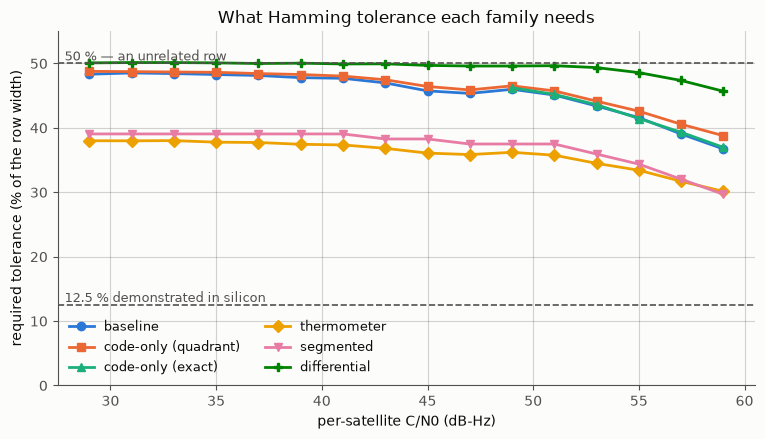

In [3]:
def series(entry, field):
    bins = entry["bins"]
    return ([b["cn0_dbhz"] for b in bins], [b[field] for b in bins])


fig, ax = plt.subplots()
for slot, (name, entry) in enumerate(families.items()):
    x, y = series(entry, "tolerance_fraction")
    ax.plot(x, np.array(y) * 100, color=PALETTE[slot], marker=MARKERS[slot],
            markersize=6, linewidth=2, label=name)

for level, text in ((SILICON, "12.5 % demonstrated in silicon"),
                    (CEILING, "50 % — an unrelated row")):
    ax.axhline(level * 100, color=MUTED, linestyle="--", linewidth=1.2)
    ax.annotate(text, xy=(0.01, level * 100), xycoords=("axes fraction", "data"),
                va="bottom", fontsize=9, color=MUTED)

ax.set(xlabel="per-satellite C/N0 (dB-Hz)",
       ylabel="required tolerance (% of the row width)",
       title="What Hamming tolerance each family needs",
       ylim=(0, 55))
ax.legend(loc="lower left", frameon=False, fontsize=9, ncols=2)
plt.show()

**Every family lands between 36 % and 50 %.** None is buildable on the macro the
proposal cites, and none is impossible either: the gap to silicon is a factor of
three to four, not a factor of one and not a factor of twenty. That is the answer
to risk 1, and it is the same answer for every arrangement of the CAM tried.

The best of them is the thermometer family at 36 %, which buys that with three
times the area — and note that its `d'` is *better* than the baseline's, not
worse. The worry in section 3 was that the extra bits would only describe the
noise and add a constant to every distance. They do not.

**One number here flatters its family.** The segmented curve is the distance to
the *best* of 15 sub-rows across 4 looks, because that is what section 4.6's
`D_true` means for a family whose hypothesis is spread over K rows. A best-of-60
statistic is not comparable with the baseline's best-of-8, and the m-of-K rule
the family actually decides with needs `min_segments` of them to match rather
than one. Read 38 % as a lower bound on what segmented needs, not as a win over
the baseline.

## 3. Separation, and the kill rule

`d' = (mean D_wrong − mean D_true) / sd D_wrong` is how many standard deviations
of the floor the right answer stands away from the wrong ones. Section 8 fixed
the rule before the runs so it could not be argued with afterwards: **a family is
dead when its d' in the 45 dB-Hz bin is below 1.0, or below half the
baseline's.**

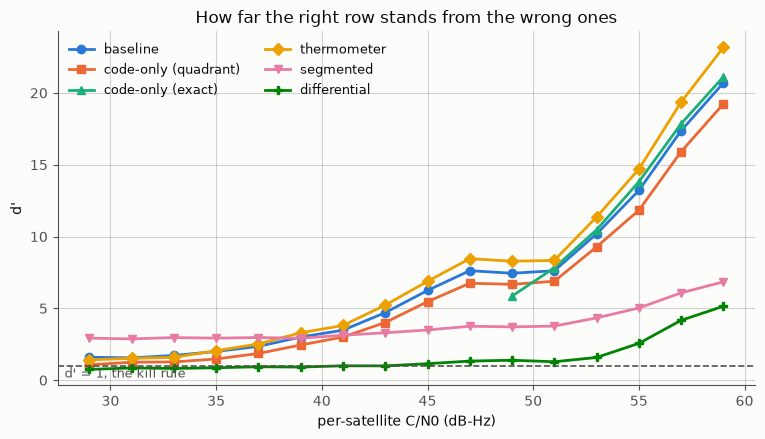

In [4]:
fig, ax = plt.subplots()
for slot, (name, entry) in enumerate(families.items()):
    x, y = series(entry, "d_prime")
    ax.plot(x, y, color=PALETTE[slot], marker=MARKERS[slot],
            markersize=6, linewidth=2, label=name)

ax.axhline(1.0, color=MUTED, linestyle="--", linewidth=1.2)
ax.annotate("d' = 1, the kill rule", xy=(0.01, 0.95),
            xycoords=("axes fraction", "data"), va="top", fontsize=9,
            color=MUTED)
ax.set(xlabel="per-satellite C/N0 (dB-Hz)", ylabel="d'",
       title="How far the right row stands from the wrong ones")
ax.legend(loc="upper left", frameon=False, fontsize=9, ncols=2)
plt.show()

In [5]:
KILL_BIN = 45.0


def at(entry, cn0_dbhz, width=2.0):
    for b in entry["bins"]:
        if abs(b["cn0_dbhz"] - cn0_dbhz) <= width / 2:
            return b
    return None


baseline = at(families["baseline"], KILL_BIN)
header = (f"{'family':22s} {'d prime':>9s} {'vs baseline':>12s} "
          f"{'tolerance':>10s} {'verdict':>10s}")
print(f"at {KILL_BIN:.0f} dB-Hz\n")
print(header)
print("-" * len(header))
for name, entry in families.items():
    b = at(entry, KILL_BIN)
    if b is None:
        print(f"{name:22s} {'no bin':>9s}")
        continue
    ratio = b["d_prime"] / baseline["d_prime"]
    dead = b["d_prime"] < 1.0 or (name != "baseline" and ratio < 0.5)
    print(f"{name:22s} {b['d_prime']:9.2f} {ratio:11.2f}x "
          f"{b['tolerance_fraction']:9.1%} {'dead' if dead else 'survives':>10s}")

at 45 dB-Hz

family                   d prime  vs baseline  tolerance    verdict
-------------------------------------------------------------------
baseline                    6.25        1.00x     45.7%   survives
code-only (quadrant)        5.47        0.87x     46.4%   survives
code-only (exact)         no bin
thermometer                 6.88        1.10x     36.1%   survives
segmented                   3.50        0.56x     38.3%   survives
differential                1.15        0.18x     49.7%       dead


**The differential family is dead**, at `d'` = 1.15 against the baseline's 6.25 —
below the half-of-baseline half of the rule, though above the absolute floor of
1.0. Section 3 predicted exactly this, for exactly this reason: per-sample signal
to noise at 40 dB-Hz is −20 dB, a delay-multiply detector goes as its square, and
the noise-times-noise penalty eats the signal. Its `D_wrong` sits at 1023.0,
which is `n_columns / 2` to four figures, and its `D_true` is barely below it.

The other three survive. Segmented does so by a margin of 12 % (3.50 against the
3.125 the rule needs), which is close enough that its full classifier, not its
screen, should decide it.

`code-only (exact)` has no 45 dB-Hz bin because it is an upper bound rather than
a design and was screened on 12 records instead of 60. Where both have
populated bins it beats the quadrant mixer by 1 to 2 in `d'`, which is the price
of keeping the front end 1 bit.

## 4. What the screen says about each family

The kill rule is only the first of three tests, and surviving it means the family
earns a calibrated measurement — not that it works.

Phase 3 calibrates every survivor and the FFT reference at a matched false alarm
rate on set A, and phase 4 measures sensitivity and CAM cost together on the 40
evaluation skies that nothing here has touched. Two of these families cannot
report a Doppler at all and are wrapped in `refine.RefinedClassifier` before they
are scored; `docs/CAM_FAMILY_STUDY.md` section 3 has the arithmetic.

In [6]:
notes = {
    "baseline": "one row per (PRN, CFO, stored phase); what the others are measured against",
    "code-only (quadrant)": "1344 rows become 64: 21x less area, 21x the latency, the same energy",
    "code-only (exact)": "a full NCO front end, so an upper bound rather than a design",
    "thermometer": "3x the area for the 1.4 dB a second bit is worth",
    "segmented": "the match line narrowed from 2046 bits to 128, at the same stored bits",
    "differential": "the carrier deleted, and the CFO with it; PRN and code phase only",
}
for name, entry in families.items():
    b = at(entry, KILL_BIN)
    print(name)
    print(f"  {notes[name]}")
    if b is None:
        print(f"  nothing landed in the {KILL_BIN:.0f} dB-Hz bin")
    else:
        print(f"  needs {b['tolerance_fraction']:.1%} of the row width at "
              f"{KILL_BIN:.0f} dB-Hz, d' {b['d_prime']:.2f}, "
              f"{b['resolution_sigma']:.1f} sigma of room below the floor")
    print()

baseline
  one row per (PRN, CFO, stored phase); what the others are measured against
  needs 45.7% of the row width at 45 dB-Hz, d' 6.25, 4.5 sigma of room below the floor

code-only (quadrant)
  1344 rows become 64: 21x less area, 21x the latency, the same energy
  needs 46.4% of the row width at 45 dB-Hz, d' 5.47, 3.5 sigma of room below the floor

code-only (exact)
  a full NCO front end, so an upper bound rather than a design
  nothing landed in the 45 dB-Hz bin

thermometer
  3x the area for the 1.4 dB a second bit is worth
  needs 36.1% of the row width at 45 dB-Hz, d' 6.88, 5.1 sigma of room below the floor

segmented
  the match line narrowed from 2046 bits to 128, at the same stored bits
  needs 38.3% of the row width at 45 dB-Hz, d' 3.50, 2.5 sigma of room below the floor

differential
  the carrier deleted, and the CFO with it; PRN and code phase only
  needs 49.7% of the row width at 45 dB-Hz, d' 1.15, 0.3 sigma of room below the floor

